<a href="https://colab.research.google.com/github/wallacecarlis/data_science/blob/main/PROJETO_10_CLUSTERING_PRODUTOS_KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

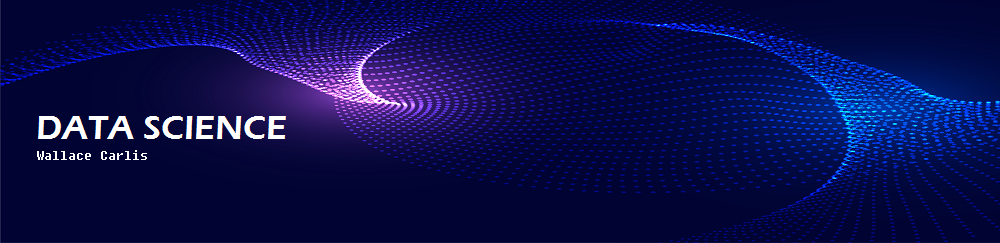

# **Projeto 10 - Clusterização de Produtos - Kmeans**

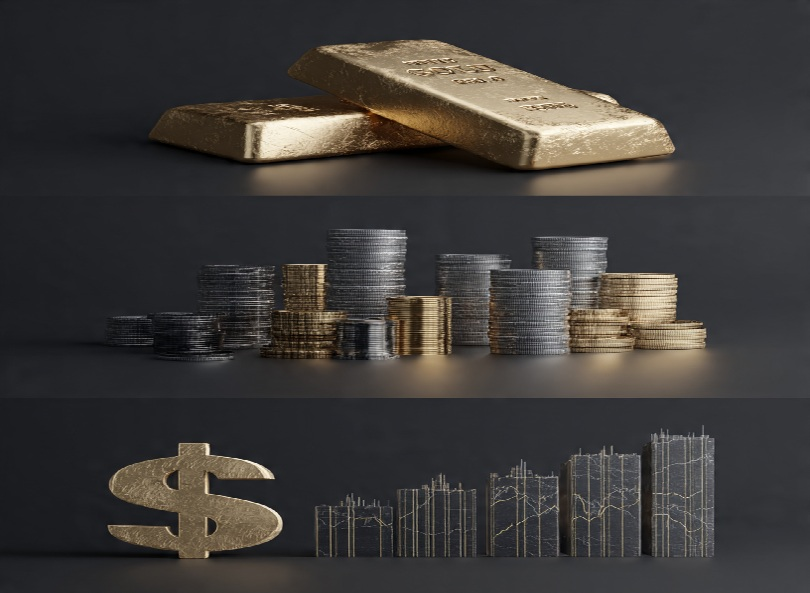

## **Clustering**


<center><img width="75%" src="https://i.imgur.com/S65Sk9c.jpg"></center>


#### **Clustering** é uma técnica de **machine learning** de aprendizado **não-supervisionado**. Na prática, são **agrupamentos de dados semelhantes** dentro de um conjuntos de dados, e um dos algoritmos mais utilizados para esta finalizade é o **[K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**. Este algoritmo calcula a **distância dos pontos** até os **centroids** de cada cluster.

## **Quantidade ideal de clusters**


<center><img width="60%" src="https://github.com/rafaelnduarte/sigmoidal_data/blob/master/Elbow_Method.png?raw=true"></center>

#### Apesar de o algoritmo **definir** por padrão a **quantidade de clusters (8)**, trata-se apenas de um **palpite**. Ou seja, o algoritmo não pode **decidir sozinho** quantos clusters utilizar, portanto, será nosso trabalho identificar a quantidade correta de clusters, e passá-la como parâmetro. Para identificar o melhor número de clusters para nossos dados, podemos utilizar, por exemplo, as seguintes métricas:

* Verificação visual dos vados;
* Conhecimento prévio sobre os dados/objetivos e um **número pré-definido** de clusters;
* E o principal, o **Elbow Method**, ou, em tradução livre, o "Método do Cotovelo". Esse método compara a distância média de cada ponto até o centro do cluster para diferentes números de clusters.




## **Padronização e Normalização**

#### Como mencionado, o **K-Means** trabalha com a **distância entre os pontos**, o que significa que ele é **altamente sensível à escala dos dados**. Por isso, é muito importante que, antes mesmo de descobrir quantos clusters vamos precisar, teremos que **padronizar ou normalizar** os dados.

#### Podemos utilizar duas classes para isso:

- O `StandardScaler` transforma os dados de forma a obter média 0 e desvio padrão 1;

- O `MinMaxScaler` coloca todos os números em uma escala entre 0 e 1;

Efetivamente, o efeito que isso faz é trazer todos os pontos para mais perto uns dos outros. A título de curiosidade, essas técnicas também ajudam a diminuir o impacto de outliers em nossos dados.

## **Centroids**

#### Ao inicializarmos a otimização dos nossos clusters, os **centroids** são inseridos **aleatoriamente nos dados**, o que significa, especialmente se não tivermos o número certo de clusters, que cada vez que inicializarmos o algoritmo, teremos clusters diferentes.

## **Base de dados**

#### A base de nosso estudo contém **32** colunas, praticamente todas binárias (valores 0 e 1), com exceção da primeira (0, 1 e 2), e quase 80k registros. Trata-se, portanto, de uma base **agnóstica**, ou seja, pode ser utilizada para permitir **insights** sobre quaisquer **agrupamentos**:

- tipos de produtos de investimentos;
- tipos de produtos de cloud-computing;
- tipos de perfis de clientes de telecom;
- tipos de pacientes de clínicas de saúde;
- tipos de veículos mais comercializados.

## **Público Alvo**

#### Talvez o principal benefício de uma **segmentação (clustering)** bem realizada é a correta compreensão do **público alvo** que a empresa pretende atingir com tal aplicação. De fato, esse é um dos pilares do **plano de negócios** e do **canvas** empresarial. Com isso em mente, vamos para nosso projeto!

In [ ]:
# 1 - Importando as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
%config InlineBackend.figure_format = "svg"
plt.rcParams["font.family"] = "sans-serif"
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [ ]:
# 2 - Acessando e visualizando os dados
arquivo = 'https://raw.githubusercontent.com/wallacecarlis/arquivos_ml/refs/heads/main/arquivo_cluster.csv'
df = pd.read_csv(arquivo)
print(df.shape)
df.head()

(79633, 32)


,um,dois,tres,quatro,cinco,seis,sete,oito,nove,dez,...,vinte_tres,vinte_quatro,vinte_cinco,vinte_seis,vinte_sete,vinte_oito,vinte_nove,trinta,trinta_um,trinta_dois
0,2,1,1,0,1,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,1,1,1,1,1,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,2,1,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
3,2,1,1,1,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2,1,0,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0


### **Normalização**

#### Uma vez que acessamos os dados, pudemos verificar que de fato praticamente todas as colunas são binárias, menos a primeira, e por isso, iremos **normalizar** a base de dados, ou seja, colocaremos todos os valores entre **0 e 1**, inclusive a primeira coluna. Faremos isso com o **Min Max Scaler**.

In [ ]:
# 3 - Normalizando os dados
scaler = MinMaxScaler()
df_normalizado = scaler.fit_transform(df)

#### Dados normalizados, vamos descobrir de quantos clusters precisaremos. Utilizaremos para isso o **KMeans** plotando um gráfico que nos trará as diferenças para cada nível de agrupamento, quanto mais **suavizada e significativa** a descida dos dados na **curva de cotovelo**, melhor. Chamaremos a variável que irá armazenar os valores de **wcss**, que na prática é a soma dos erros de cada ponto até o seu centróide. Isso a cada rodada de agrupamentos, faremos isso por 15 vezes.

### **Elbow Method**
#### Plotando o gráfico de cotovelo

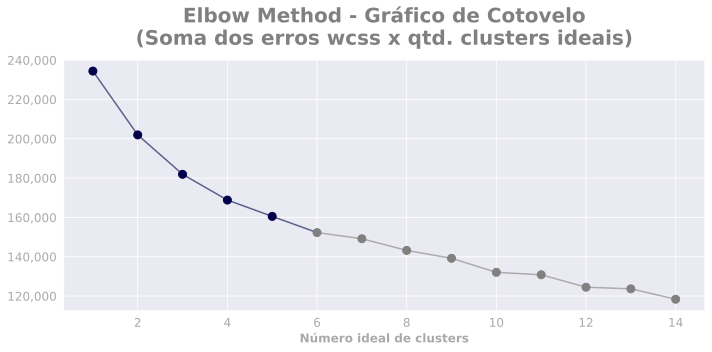

In [ ]:
# 4 - Gráfico de cotovelo
wcss = []
inicio = 1
fim = 15

for i in range(inicio, fim):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300,
                  n_init = 10, random_state = 0)
  kmeans.fit(df_normalizado)
  wcss.append(kmeans.inertia_)

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)
x_lista = list(range(inicio, fim))
x_azul = x_lista[:6]
y_azul = wcss[:6]
x_grey = x_lista[5:]
y_grey = wcss[5:]
ax.plot(x_azul, y_azul, linestyle = "-", alpha = 0.6, color = "#00004a")
ax.plot(x_grey, y_grey, linestyle = "-", alpha = 0.6, color = "grey")

for idx, val in enumerate(wcss):
  cor = "#00004a" if idx < 5 else "grey"
  ax.plot(inicio + idx, val, marker = "o", markersize = 8, color = cor)

ax.set_title("Elbow Method - Gráfico de Cotovelo\n(Soma dos erros wcss x qtd. clusters ideais)",
             fontsize = 20, fontweight = "bold", color = "grey", pad = 15)
ax.set_ylabel("")
ax.set_xlabel("Número ideal de clusters", fontsize = 12, color = "darkgrey", fontweight = "semibold")
ax.tick_params(axis = "y", labelsize = 12, colors = "darkgrey")
ax.tick_params(axis = "x", labelsize = 12, colors = "darkgrey")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()

#### A visualização do gráfico acima já nos deu uma boa noção de quantos clusters realmente poderemos utilizar. Contudo, criaremos uma tabela para confirmar a assertividade das informações:
- criaremos um dataframe com os erros do wcss;
- criaremos um dataframe com a diferença dos erros.

In [ ]:
# 5 - Tabela para visualização de erros
df_wcss = pd.DataFrame(wcss, columns = ["wcss_erros"])
dif = np.diff(wcss)
df_diff = pd.DataFrame(dif, columns = ["diff_erros"])
df_concat = pd.concat([df_wcss, df_diff], axis = 1)
df_concat

,wcss_erros,diff_erros
0,234446.457543,-32469.072213
1,201977.385330,-20041.537683
2,181935.847647,-13102.003601
3,168833.844046,-8295.468707
4,160538.375339,-8246.486112
5,152291.889227,-3119.530945
6,149172.358282,-5952.593318
7,143219.764964,-4014.284076
8,139205.480888,-7118.878014
9,132086.602874,-1252.210666


#### Ao olharmos detalhadamente e compararmos as colunas da tabela concatenada acima, podemos perceber que no **índice 5**, ou seja, na **sexta comparação**, ocorreu a **diferença mais suavizada e significativa**. Ainda que no **índice 11** tenha ocorrido o **menor valor**, contudo, não houve **significância** deste valor de erro. Portanto, utilizaremos a **sexta comparação**, logo, **6 clusters**.

In [ ]:
# 6 - Definição da quantidade de clusters
numero_de_clusters = 6

### **KMeans**

In [ ]:
# 7 - Aplicação do algoritmo e criação da variável dos clusters
kmeans = KMeans(n_clusters = numero_de_clusters, init = "k-means++",
                max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(df_normalizado)
print(y_kmeans.shape)
y_kmeans

(79633,)


array([2, 2, 4, ..., 5, 1, 3], dtype=int32)

#### Acima, criamos uma variável chamada **y_kmeans** que recebeu a **definição dos clusters**. Agora vamos:
- transformá-la em um **dataframe**;
- uni-la com nossa base **original** que chamaremos **df_clusters**;
- criar uma coluna **produto x**;
- visualizar as **segmentações** em um gráfico.

In [ ]:
# 8 - Concatenando as previsões
df_kmeans = pd.DataFrame(data = y_kmeans, dtype = int)
df_kmeans.columns = ["cluster"]
df_clusters = pd.concat([df_kmeans, df], axis = 1)
df_clusters["produto"] = ["Produto " + x for x in df_clusters["cluster"].astype(str)]
print(df_clusters.shape)
df_clusters.head()

(79633, 34)


,cluster,um,dois,tres,quatro,cinco,seis,sete,oito,nove,...,vinte_quatro,vinte_cinco,vinte_seis,vinte_sete,vinte_oito,vinte_nove,trinta,trinta_um,trinta_dois,produto
0,2,2,1,1,0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,Produto 2
1,2,1,1,1,1,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,Produto 2
2,4,2,1,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,Produto 4
3,4,2,1,1,1,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,Produto 4
4,1,2,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,Produto 1


#### Conforme verificado acima, a primeira coluna da base é a **definição do cluster** pelo **KMeans**. E a última coluna é basicamente uma cópia da primeira criada justamente para facilitar a visualização no gráfico. Para isso, iremos criar uma nova base somente com o **agrupamento** dos valores da última coluna **(produtos)**.

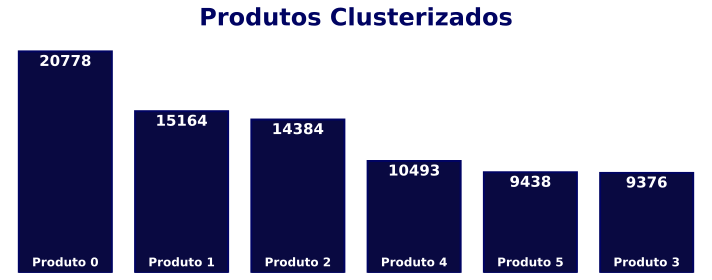

In [ ]:
# 9 - Gráfico dos clusters
clusters = df_clusters.groupby(["produto"]).size().sort_values(ascending = False)
clusters = pd.DataFrame(clusters).reset_index().rename(columns = {0 : "qtd"})

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 4), dpi = 300)
barras = sns.barplot(data = clusters, x = "produto", y = "qtd", orient = "v", color = "#00004a")

for i in barras.patches:
  i.set_edgecolor("#000362")
  i.set_linewidth(2.0)
  ax.annotate(int(i.get_height()),
              xy = (i.get_x() + (i.get_width() / 2),
                    i.get_height() - (i.get_width() * clusters.qtd.max() * 0.05)),
              va = "center_baseline", ha = "center", color = "white",
              fontsize = 15, fontweight = "bold")

for i in range(len(clusters)):
  nome = clusters.loc[i, "produto"]
  valor = clusters.loc[i, "qtd"]
  ax.text(i, clusters.qtd.max() * 0.05, nome, color = "white", fontsize = 12,
          va = "center_baseline", ha = "center", fontweight = "semibold")

ax.set_title("Produtos Clusterizados", fontsize = 24, fontweight = "bold",
             color = "#000362", pad = 15)
ax.axis("off")
plt.tight_layout()

### **Concluindo:**

#### Como mencionado, o algoritmo **Kmeans** é um dos principais utilizados quando o assunto é **clusterização**, ou **segmentação**. É também altamente sensível aos **outliers**, por isso, deve-se tratar a base previamente com classes de **padronização ou normalização** dos dados. No nosso caso, optamos tecnicamente pela **normalização**, pois queríamos valores entre **0 e 1**. Vale lembrar os parâmetros utilizados como **número de clusters** ou **número máximo de iterações**, e obviamente, isso está na **documentação do modelo**, cujo link está no início deste projeto, bastando clicar no **nome do algoritmo** para acessá-la.

#### Utilizamos uma base já transformada em valores praticamente binários, portanto, caso sua base não esteja no formato, será impresncindível tratá-la e deixá-la assim. Pode-se utilizar tanto o método **get_dummies** do **pandas** para isso, quanto a classe **One Hot Encoder** do **scikit-learn**, isso para colunas **binárias**. Caso as colunas não sejam **binárias**, poderão ser tratadas com a classe **Label Encoder**. Estes temas são tratados no meu curso **PANDAS TWO**, que será lançado em breve.

#### Como case, vale muita a pena compreender o quão **significante** para uma empresa é **conhecer** detalhadamente seus **clientes** a partir de seus **perfis**. Com certeza isso é parte fundamental da **assertividade** de suas **vendas**. Pois tecnicamente, no final do dia, trata-se de **agrupamentos corretos** para **maximizar lucros** e **minimizar perdas**. Seja qual for sua empresa, um banco pensando numa **cesta de investimentos**, uma consultoria pensando nos **produtos cloud** a serem comercializados, ou uma concessionária de veículos pensando em quais **categorias de veículos** seus consumidores comprarão, por exemplo. Portanto, conhecer e definir o **público alvo** é talvez o principal **benefício** que a **clusterização** pode nos trazer.

#### Muito obrigado pela leitura. Caso tenha interesse em analisar outros projetos fique à vontade acessando diretamente meu [GitHub](https://github.com/wallacecarlis/data_science), [Medium](https://wallacecarlis.medium.com/), e meu [Site](https://www.wallacecarlis.com/). Todo feedback será bem-vindo, abs!